#Convolutional Layer

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##1.  Simple CNN Implemented using Keras.

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
#Loadasample dataset(MNISTforsimplicity)
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()
#Normalizeand reshapedata
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
x_train=np.expand_dims(x_train,axis=-1)#Addchanneldimension
x_test=np.expand_dims(x_test,axis=-1)
#Defineasimple CNNmodel
model =keras.Sequential([
layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)),
layers.MaxPooling2D((2,2)),
layers.Conv2D(64,(3,3),activation="relu"),
layers.MaxPooling2D((2,2)),
layers.Flatten(),
layers.Dense(128,activation="relu"),
layers.Dense(10,activation="softmax")#10classesforMNISTdigits
])
#Compilethemodel
model.compile(optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"])
#Trainthemodel
model.fit(x_train,y_train,epochs=5,batch_size=32,validation_data=(x_test,y_test))
#Evaluatethemodel
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f"Testaccuracy:{test_acc:.4f}")
#Makepredictions
predictions=model.predict(x_test[:5])
predicted_labels =np.argmax(predictions,axis=1)
print("Predictedlabels:",predicted_labels)
print("Actuallabels:",y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.9626 - loss: 0.1229 - val_accuracy: 0.9860 - val_loss: 0.0409
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9875 - loss: 0.0413 - val_accuracy: 0.9910 - val_loss: 0.0281
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 37ms/step - accuracy: 0.9917 - loss: 0.0280 - val_accuracy: 0.9883 - val_loss: 0.0356
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accuracy: 0.9932 - loss: 0.0205 - val_accuracy: 0.9886 - val_loss: 0.0346
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9954 - loss: 0.0145 - val_accuracy: 0.9910 - val_loss: 0.0290
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9910 - loss: 0.0290
Testaccuracy:0.9910
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predictedlabels: [7 2 1 0 4]
Actuallabels: [7 2 1 0 4]


In [13]:
input_shape=(28,28,1)

In [14]:
layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)),

(<Conv2D name=conv2d_2, built=False>,)

In [15]:
layers.MaxPooling2D((2, 2)),

(<MaxPooling2D name=max_pooling2d_3, built=True>,)

In [ ]:
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),

In [ ]:
layers.MaxPooling2D((2, 2)),

In [16]:
layers.Flatten(),

(<Flatten name=flatten_1, built=False>,)

In [17]:
layers.Dense(128, activation="relu"),

(<Dense name=dense_2, built=False>,)

In [18]:
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits

<Dense name=dense_3, built=False>

#Exercise

##Implement an End to End CNN Model for Image Classification Task.


##Task 1: Data Understanding and Visualization:

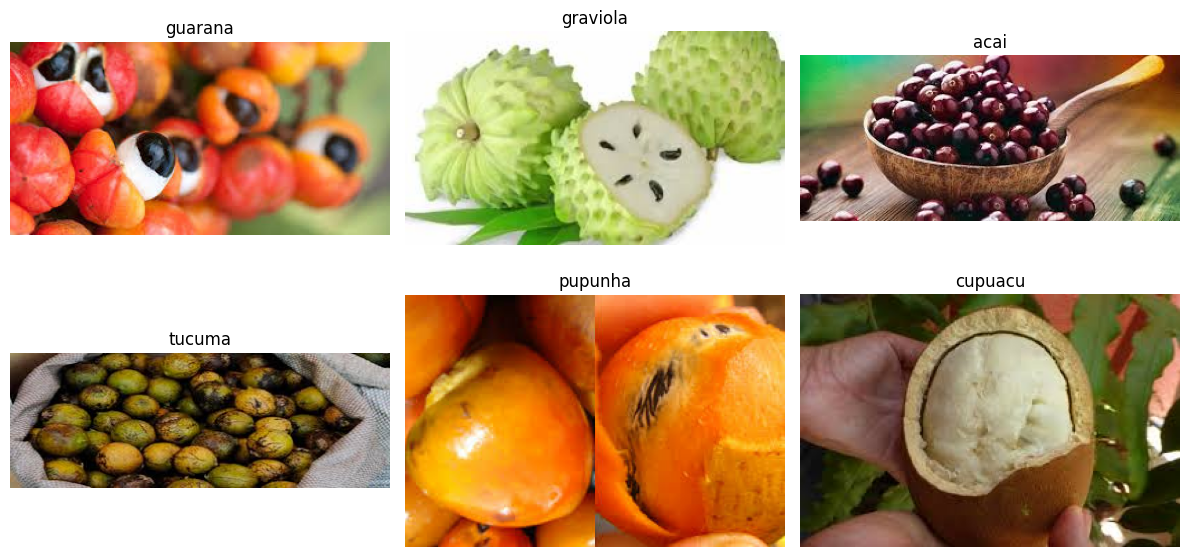

In [19]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon/train"  # change this

# Get class names
class_names = os.listdir(train_dir)

images = []
titles = []

# Select one random image per class
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)
        images.append(img)
        titles.append(class_name)

# Plot in grid (2 rows)
cols = len(images) // 2 + len(images) % 2

plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

##Task2: Loading and Preprocessing Image Data in keras:

In [25]:
train_ds=tf.keras.preprocessing.image_dataset_from_directory(train_dir,labels='inferred',
label_mode='int',image_size=(img_height,img_width),interpolation='nearest',batch_size=
batch_size,shuffle=True,validation_split=validation_split,subset='training',seed=123)

Found 90 files belonging to 6 classes.
Using 72 files for training.


###Sample Implementation.

In [24]:
import tensorflow as tf

# Define image size and batch size
img_height = 128  # Example image height
img_width = 128   # Example image width
batch_size = 32
validation_split = 0.2  # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)  # Normalize pixel values to [0,1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the valida
val_ds = val_ds.map(lambda x, y : (rescale(x),y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


###Normalization (Rescaling):

In [26]:
rescale=tf.keras.layers.Rescaling(1./255)#Normalizepixelvaluesto[0,1]

### Image and Batch Size Parameters:

In [27]:
img_height=128 #Reshapestoimageheight
img_width=128 #Reshapesimagewidth
batch_size=32
validation_split=0.2 #80%training,20%validation

##Task 3 Implement a CNN with
Follow the following Structure and Hyper- parameters:

In [29]:
from tensorflow.keras import layers, models

# Define number of classes (IMPORTANT)
num_classes = len(train_ds.class_names)

model = models.Sequential([

    # Input Layer (fix for warning)
    layers.Input(shape=(128,128,3)),

    # Convolutional Layer 1
    layers.Conv2D(32, (3,3), strides=1, padding='same'),
    layers.Activation('relu'),

    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3,3), strides=1, padding='same'),
    layers.Activation('relu'),

    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

##Task 4: Compile the Model

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Task 4: Train the Model

In [32]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Callback: Save best model
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Callback: Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9797 - loss: 0.1561
Epoch 1: val_accuracy improved from None to 0.55556, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 869ms/step - accuracy: 0.9861 - loss: 0.1466 - val_accuracy: 0.5556 - val_loss: 1.7702
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9902 - loss: 0.0583
Epoch 2: val_accuracy improved from 0.55556 to 0.61111, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 582ms/step - accuracy: 0.9861 - loss: 0.0595 - val_accuracy: 0.6111 - val_loss: 1.7600
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 1.0000 - loss: 0.0228
Epoch 3: val_accuracy improved from 0.61111 to 0.77778, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 532ms/step - accuracy: 1.0000 - loss: 0.0256 - val_accuracy: 0.7778 - val_loss: 1.7503
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 1.0000 - loss: 0.0066
Epoch 4: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 0.7778 - val_loss: 1.7471
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 1.0000 - loss: 9.5114e-04
Epoch 5: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step - accuracy: 1.0000 - loss: 8.3674e-04 - val_accuracy: 0.7222 - val_loss: 1.7468
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 1.0000 - loss: 4.3717e-04
Epoch 6: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 812ms/step - accuracy: 1.0000 - loss: 4.2613e-04 - val_accuracy: 0.7222 - val_loss: 1.7461
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 1.0000 -

##Task 5: Evaluate the Model

In [33]:
# Evaluate the model on test/validation dataset
test_loss, test_accuracy = model.evaluate(val_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.7778 - loss: 1.7322
Test Loss: 1.7321677207946777
Test Accuracy: 0.7777777910232544


##Task 6: Save and Load the Model

In [34]:
# Save the trained model
model.save("final_model.h5")

# Load the saved model
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")

# Re-evaluate on test/validation dataset
loss, accuracy = loaded_model.evaluate(val_ds)

print("Loaded Model Loss:", loss)
print("Loaded Model Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step - accuracy: 0.7778 - loss: 1.7322
Loaded Model Loss: 1.7321677207946777
Loaded Model Accuracy: 0.7777777910232544


##Task 7: Predictions and Classification Report

In [36]:
from sklearn.metrics import classification_report
import numpy as np

# Get unique labels present in predictions/true labels
labels = sorted(list(set(y_true) | set(y_pred)))

report = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=[train_ds.class_names[i] for i in labels]
)

print(report)

              precision    recall  f1-score   support

     cupuacu       0.00      0.00      0.00         0
     pupunha       1.00      0.67      0.80         3
      tucuma       1.00      0.80      0.89        15

    accuracy                           0.78        18
   macro avg       0.67      0.49      0.56        18
weighted avg       1.00      0.78      0.87        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
